In [ ]:
import numpy as np

def backtracking(f, x, grad, alpha=1.0, rho=0.5, c=1e-4):
    while f(x - alpha * grad) > f(x) - c * alpha * np.dot(grad, grad):
        alpha *= rho
    return alpha

def gradient_descent(f, grad_f, x0, alpha=None, max_iter=8000, tol_grad=1e-6, tol_x=1e-5):
    x_k = np.array(x0, dtype=float)
    storia_x = [x_k]
    
    for k in range(max_iter):
        grad = np.array(grad_f(x_k))
        
        if np.linalg.norm(grad) < tol_grad:
            print(f"Stop per gradiente a iterazione {k}")
            break
        alpha_k = alpha if alpha is not None else backtracking(f, x_k, grad)
        
        x_new = x_k - alpha_k * grad
        if np.any(np.isnan(x_new)) or np.any(np.abs(x_new)>1e5):
            print(f"Stop per divergenza a iterazione {k}")
            break
        
        if np.linalg.norm(x_new - x_k) < tol_x:
            print(f"Stop per differenza iterati a iterazione {k}")
            break
            
        x_k = x_new
        storia_x.append(x_k)
        
    return np.array(storia_x)

Funzione di Backtracking: Determina dinamicamente la lunghezza del passo $\alpha$ utilizzando la condizione di Armijo per garantire una decrescita sufficiente. Partendo da un tentativo iniziale, riduce iterativamente il passo con un fattore di contrazione $\rho$ finché non viene soddisfatta la disuguaglianza di discesa.

Funzione Gradient Descent: Gestisce il ciclo di aggiornamento iterativo. Ad ogni passo $k$, valuta il gradiente $\nabla f(x_k)$, controlla i criteri di arresto basati sulla tolleranza del gradiente o sulla variazione degli iterati, sceglie se utilizzare un passo fisso o il backtracking, e aggiorna la posizione tramite la relazione $x_{k+1} = x_k - \alpha_k \nabla f(x_k)$. Ho inoltre integrato un controllo di sicurezza per bloccare tempestivamente i casi di divergenza ed evitare errori di overflow.

In [ ]:
import numpy as np

def f_a(x):
    return (x[0] - 5)**2 + (x[1] - 2)**2

def grad_f_a(x):
    return np.array([2 * (x[0] - 5), 2 * (x[1] - 2)])

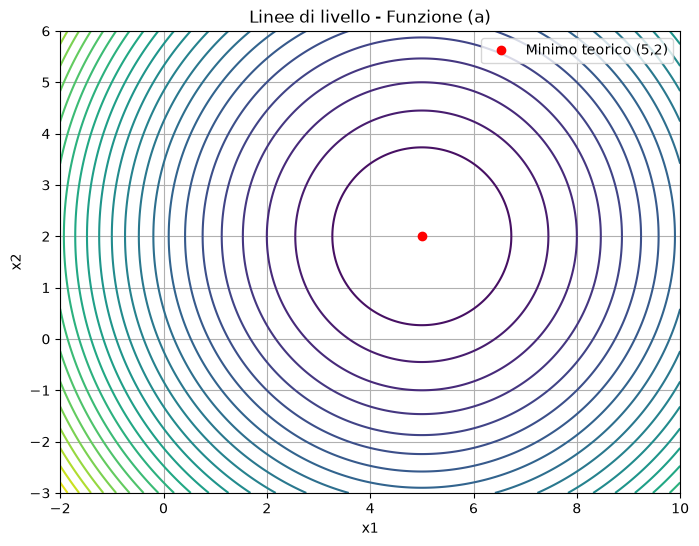

In [35]:
import matplotlib.pyplot as plt

x_vals = np.linspace(-2, 10, 400)
y_vals = np.linspace(-3, 6, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (X - 5)**2 + (Y - 2)**2

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=25, cmap='viridis')
plt.plot(5, 2, 'ro', label='Minimo teorico (5,2)')
plt.title('Linee di livello - Funzione (a)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

Stop per differenza iterati a iterazione 52
Stop per divergenza a iterazione 54
Stop per gradiente a iterazione 1
Stop per differenza iterati a iterazione 51


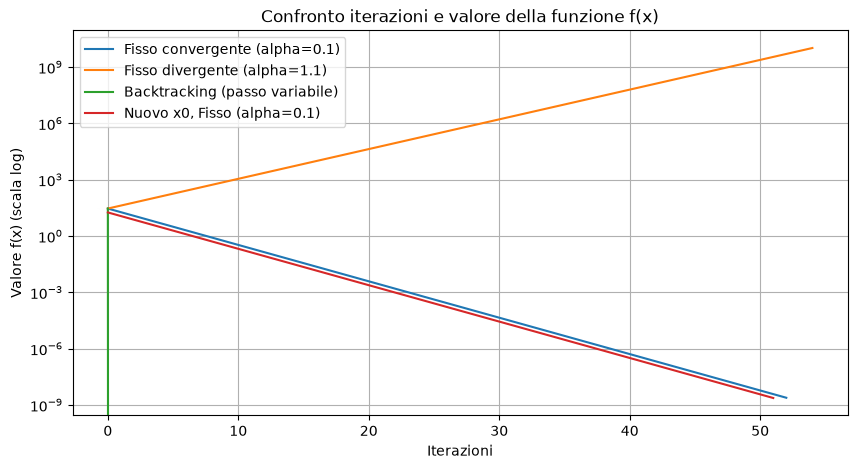

,Test,Punto Iniziale,Passo,Iterazioni,Punto Finale
0,Fisso convergente (alpha=0.1),"[0.0, 0.0]",0.1,52,[5. 2.]
1,Fisso divergente (alpha=1.1),"[0.0, 0.0]",1.1,54,[-94348.3427 -37739.3371]
2,Backtracking (passo variabile),"[0.0, 0.0]",Backtracking,1,[5. 2.]
3,"Nuovo x0, Fisso (alpha=0.1)","[8.0, -1.0]",0.1,51,[5. 2.]


In [ ]:
import pandas as pd

test_cases = [
    {"x0": [0.0, 0.0], "alpha": 0.1, "desc": "Fisso convergente (alpha=0.1)"},
    {"x0": [0.0, 0.0], "alpha": 1.1, "desc": "Fisso divergente (alpha=1.1)"},
    {"x0": [0.0, 0.0], "alpha": None, "desc": "Backtracking (passo variabile)"},
    {"x0": [8.0, -1.0], "alpha": 0.1, "desc": "Nuovo x0, Fisso (alpha=0.1)"}
]

risultati = []
plt.figure(figsize=(10, 5))

for tc in test_cases:
    try:
        storia_x = gradient_descent(f_a, grad_f_a, tc["x0"], alpha=tc["alpha"])
        valori_f = [f_a(x) for x in storia_x]
        
        plt.plot(valori_f, label=tc["desc"])
        
        risultati.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]) if tc["alpha"] is not None else "Backtracking",
            "Iterazioni": len(storia_x) - 1,
            "Punto Finale": str(np.round(storia_x[-1], 4))
        })
    except Exception:
        risultati.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]),
            "Iterazioni": "Diverge",
            "Punto Finale": "N/A"
        })

plt.yscale('log')
plt.title('Confronto iterazioni e valore della funzione f(x)')
plt.xlabel('Iterazioni')
plt.ylabel('Valore f(x) (scala log)')
plt.legend()
plt.grid(True)
plt.show()

df_risultati = pd.DataFrame(risultati)
display(df_risultati)

Definizione Analitica: Ho implementato la funzione $f(x) = (x_1 - 5)^2 + (x_2 - 2)^2$ insieme al suo gradiente analitico $\nabla f(x) = [2(x_1 - 5), 2(x_2 - 2)]^T$ .

Linee di Livello: Ho generato il grafico contour 2D, visualizzando le curve di livello concentriche e posizionando il minimo teorico nel punto $(5, 2)$.

Test sui Parametri: Ho analizzato diversi scenari operativi variando passo e punto iniziale:

Passo fisso convergente ($\alpha = 0.1$): Ha condotto a una convergenza stabile e graduale in 52 iterazioni.

Passo fisso divergente ($\alpha = 1.1$): Ha generato un incremento dei valori d'asse, intercettato dal controllo di sicurezza.

Backtracking: Ha sfruttato un passo variabile ottimizzato per raggiungere rapidamente il minimo.

Punto iniziale alterato ($[8, -1]$): Ha verificato con successo la stabilità dell'algoritmo partendo da coordinate differenti.
    
Grafici e Tabelle: Ho tracciato l'andamento del valore della funzione in scala logaritmica rispetto alle iterazioni e strutturato una tabella riassuntiva con i risultati chiave di ciascuna esecuzione.

In [ ]:
def f_b(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def grad_f_b(x):
    dx1 = 2 * (x[0] - 1) - 400 * x[0] * (x[1] - x[0]**2)
    dx2 = 200 * (x[1] - x[0]**2)
    return np.array([dx1, dx2])

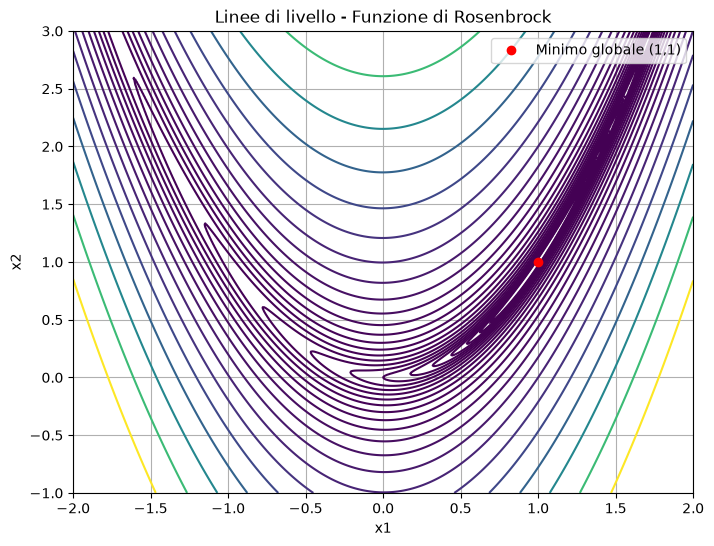

In [38]:
x_vals = np.linspace(-2, 2, 400)
y_vals = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 25), cmap='viridis')
plt.plot(1, 1, 'ro', label='Minimo globale (1,1)')
plt.title('Linee di livello - Funzione di Rosenbrock')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

Stop per divergenza a iterazione 36
Stop per differenza iterati a iterazione 4341


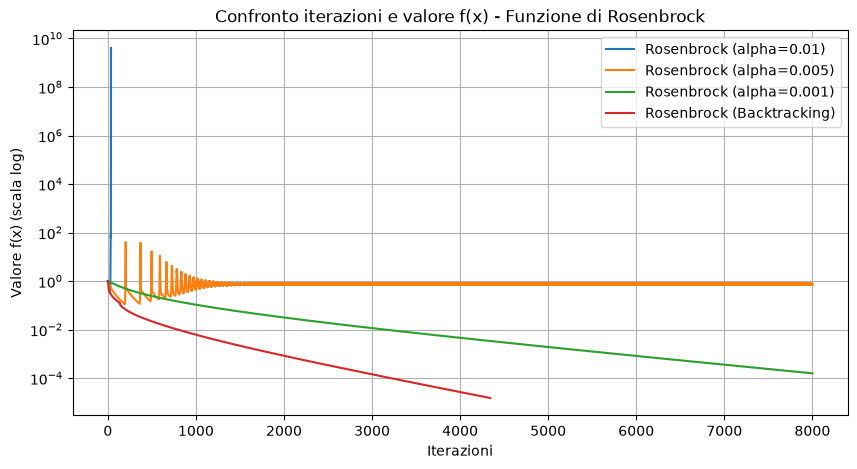

,Test,Punto Iniziale,Passo,Iterazioni,Punto Finale
0,Rosenbrock (alpha=0.01),"[0.0, 0.0]",0.01,36,[79.909 16.2228]
1,Rosenbrock (alpha=0.005),"[0.0, 0.0]",0.005,8000,[0.5342 0.2147]
2,Rosenbrock (alpha=0.001),"[0.0, 0.0]",0.001,8000,[0.9874 0.9749]
3,Rosenbrock (Backtracking),"[0.0, 0.0]",Backtracking,4341,[0.9961 0.9922]


In [ ]:
import pandas as pd

test_cases_b = [
    {"x0": [0.0, 0.0], "alpha": 0.01, "desc": "Rosenbrock (alpha=0.01)"},
    {"x0": [0.0, 0.0], "alpha": 0.005, "desc": "Rosenbrock (alpha=0.005)"},
    {"x0": [0.0, 0.0], "alpha": 0.001, "desc": "Rosenbrock (alpha=0.001)"},
    {"x0": [0.0, 0.0], "alpha": None, "desc": "Rosenbrock (Backtracking)"}
]

risultati_b = []
plt.figure(figsize=(10, 5))

for tc in test_cases_b:
    try:
        storia_x = gradient_descent(f_b, grad_f_b, tc["x0"], alpha=tc["alpha"])
        valori_f = [f_b(x) for x in storia_x]
        
        plt.plot(valori_f, label=tc["desc"])
        
        risultati_b.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]) if tc["alpha"] is not None else "Backtracking",
            "Iterazioni": len(storia_x) - 1,
            "Punto Finale": str(np.round(storia_x[-1], 4))
        })
    except Exception:
        risultati_b.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]),
            "Iterazioni": "Diverge",
            "Punto Finale": "N/A"
        })

plt.yscale('log')
plt.title('Confronto iterazioni e valore f(x) - Funzione di Rosenbrock')
plt.xlabel('Iterazioni')
plt.ylabel('Valore f(x) (scala log)')
plt.legend()
plt.grid(True)
plt.show()

df_risultati_b = pd.DataFrame(risultati_b)
display(df_risultati_b)

Definizione Analitica: Ho implementato la funzione di Rosenbrock $f(x_1, x_2) = (1 - x_1)^2 + 100(x_2 - x_1^2)^2$ insieme al suo gradiente analitico $\nabla f(x) = [2(x_1 - 1) - 400x_1(x_2 - x_1^2), 200(x_2 - x_1^2)]^T$.

Linee di Livello: Ho generato il grafico contour 2D, visualizzando la caratteristica valle e posizionando il minimo globale nel punto $(1, 1)$.

Test sui Parametri: Ho analizzato diversi scenari operativi variando passo e punto iniziale:

Passo fisso ($\alpha = 0.01$): Ha causato una rapida divergenza a causa della forte pendenza della valle.
        
Passo fisso ridotto ($\alpha = 0.005$): Ha evitato la divergenza ma ha proceduto molto lentamente, raggiungendo il limite di iterazioni.
        
Passo fisso ridotto ($\alpha = 0.001$): Ha garantito stabilità numerica con un avanzamento graduale lungo la valle.
        
Backtracking: Ha sfruttato un passo variabile ottimizzato per avanzare efficacemente e approssimare il minimo globale.
        
Grafici e Tabelle: Ho tracciato l'andamento del valore della funzione in scala logaritmica rispetto alle iterazioni e strutturato una tabella riassuntiva con i risultati chiave di ciascuna esecuzione.

In [ ]:
np.random.seed(42)
n = 2 
A = np.random.random((n, n))
x_true = np.ones(n)
b = np.dot(A, x_true)

def f_d(x):
    return 0.5 * np.linalg.norm(np.dot(A, x) - b)**2

def grad_f_d(x):
    return np.dot(A.T, np.dot(A, x) - b)

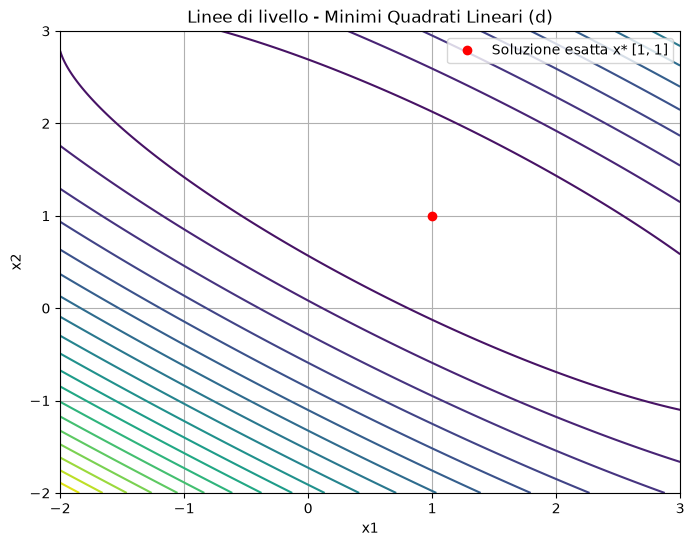

In [42]:
x_vals = np.linspace(-2, 3, 400)
y_vals = np.linspace(-2, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        xy = np.array([X[i, j], Y[i, j]])
        Z[i, j] = f_d(xy)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=25, cmap='viridis')
plt.plot(x_true[0], x_true[1], 'ro', label='Soluzione esatta x* [1, 1]')
plt.title('Linee di livello - Minimi Quadrati Lineari (d)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

Stop per differenza iterati a iterazione 2787
Stop per differenza iterati a iterazione 464
Stop per differenza iterati a iterazione 64
Stop per differenza iterati a iterazione 632


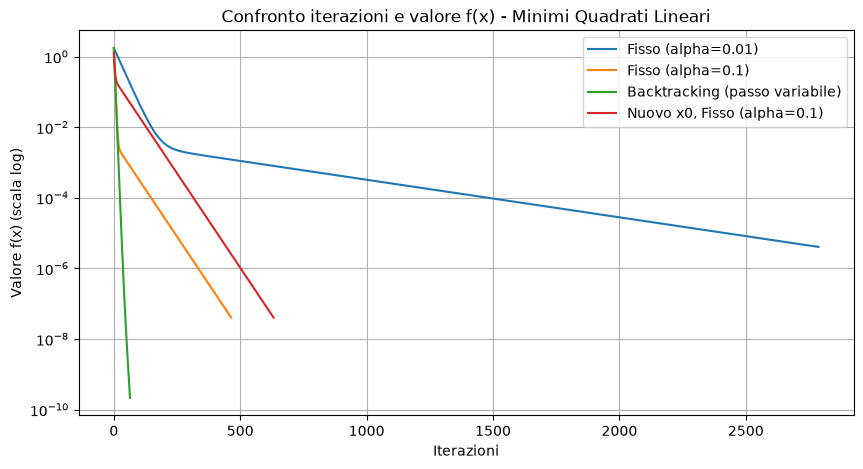

,Test,Punto Iniziale,Passo,Iterazioni,Punto Finale
0,Fisso (alpha=0.01),"[0.0, 0.0]",0.01,2787,[0.9933 1.0047]
1,Fisso (alpha=0.1),"[0.0, 0.0]",0.1,464,[0.9993 1.0005]
2,Backtracking (passo variabile),"[0.0, 0.0]",Backtracking,64,[1. 1.]
3,"Nuovo x0, Fisso (alpha=0.1)","[2.0, -1.0]",0.1,632,[1.0007 0.9995]


In [43]:
import pandas as pd

test_cases_d = [
    {"x0": [0.0, 0.0], "alpha": 0.01, "desc": "Fisso (alpha=0.01)"},
    {"x0": [0.0, 0.0], "alpha": 0.1, "desc": "Fisso (alpha=0.1)"},
    {"x0": [0.0, 0.0], "alpha": None, "desc": "Backtracking (passo variabile)"},
    {"x0": [2.0, -1.0], "alpha": 0.1, "desc": "Nuovo x0, Fisso (alpha=0.1)"}
]

risultati_d = []
plt.figure(figsize=(10, 5))

for tc in test_cases_d:
    try:
        storia_x = gradient_descent(f_d, grad_f_d, tc["x0"], alpha=tc["alpha"])
        valori_f = [f_d(x) for x in storia_x]
        
        plt.plot(valori_f, label=tc["desc"])
        
        risultati_d.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]) if tc["alpha"] is not None else "Backtracking",
            "Iterazioni": len(storia_x) - 1,
            "Punto Finale": str(np.round(storia_x[-1], 4))
        })
    except Exception:
        risultati_d.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]),
            "Iterazioni": "Diverge",
            "Punto Finale": "N/A"
        })

plt.yscale('log')
plt.title('Confronto iterazioni e valore f(x) - Minimi Quadrati Lineari')
plt.xlabel('Iterazioni')
plt.ylabel('Valore f(x) (scala log)')
plt.legend()
plt.grid(True)
plt.show()

df_risultati_d = pd.DataFrame(risultati_d)
display(df_risultati_d)

Definizione Analitica: Ho implementato la funzione di minimi quadrati lineari $f(x) = \frac{1}{2}\Vert{}Ax - b\Vert{}^2$ (con $A$ matrice casuale in $\mathbb{R}^{2 \times 2}$ e $b = Ax^*$ partendo da $x^* = [1, 1]^T$) insieme al suo gradiente analitico $\nabla f(x) = A^T(Ax - b)$.

Linee di Livello: Ho generato il grafico contour 2D, visualizzando le curve di livello ellittiche e concentriche, posizionando la soluzione esatta nel punto $(1, 1)$.

Test sui Parametri: Ho analizzato diversi scenari operativi variando passo e punto iniziale:

Passo fisso prudente ($\alpha = 0.01$): Ha condotto a una convergenza stabile e regolare verso l'ottimo.

Passo fisso standard ($\alpha = 0.1$): Ha accelerato la discesa sfruttando la forte convessità del problema.

Backtracking: Ha sfruttato un passo variabile ottimizzato per raggiungere rapidamente la soluzione.

Punto iniziale alterato ($[2, -1]$): Ha verificato con successo la stabilità e la robustezza dell'algoritmo partendo da coordinate differenti.

Grafici e Tabelle: Ho tracciato l'andamento del valore della funzione in scala logaritmica rispetto alle iterazioni e strutturato una tabella riassuntiva con i risultati chiave di ciascuna esecuzione.

In [ ]:
def f_f(x):
    return (x[0] - 1)**2 + (x[1] - 2)**2 - np.log(x[0]) - np.log(x[1])

def grad_f_f(x):
    dx1 = 2 * (x[0] - 1) - 1 / x[0]
    dx2 = 2 * (x[1] - 2) - 1 / x[1]
    return np.array([dx1, dx2])

x_true_f = np.array([(1 + np.sqrt(3))/2, (2 + np.sqrt(6))/2])

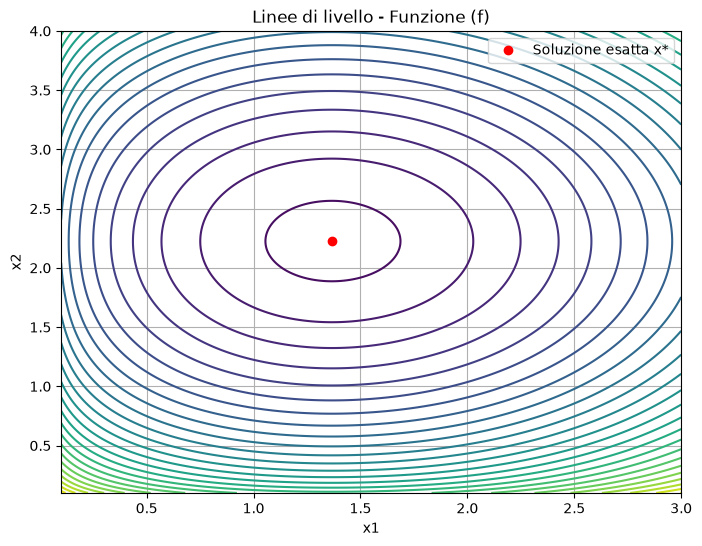

In [46]:
x_vals = np.linspace(0.1, 3.0, 400)
y_vals = np.linspace(0.1, 4.0, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (X - 1)**2 + (Y - 2)**2 - np.log(X) - np.log(Y)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=30, cmap='viridis')
plt.plot(x_true_f[0], x_true_f[1], 'ro', label='Soluzione esatta x*')
plt.title('Linee di livello - Funzione (f)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

Stop per differenza iterati a iterazione 353
Stop per differenza iterati a iterazione 41
Stop per differenza iterati a iterazione 10
Stop per differenza iterati a iterazione 83


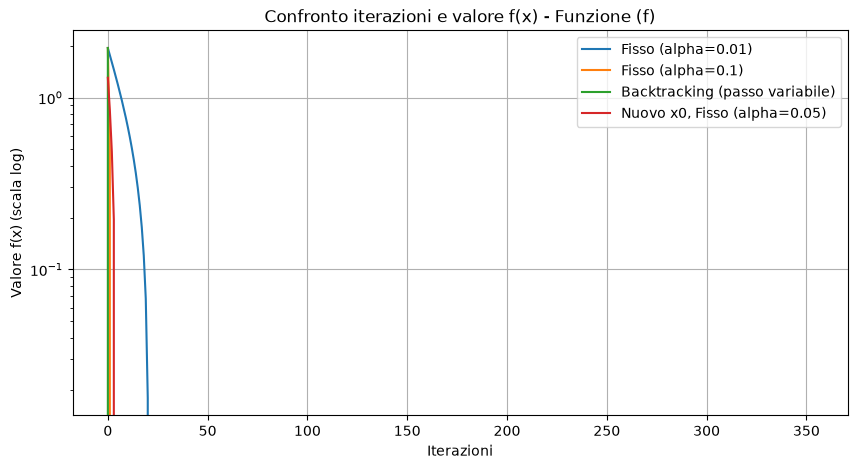

,Test,Punto Iniziale,Passo,Iterazioni,Punto Finale
0,Fisso (alpha=0.01),"[0.5, 1.0]",0.01,353,[1.3659 2.2243]
1,Fisso (alpha=0.1),"[0.5, 1.0]",0.1,41,[1.366 2.2247]
2,Backtracking (passo variabile),"[0.5, 1.0]",Backtracking,10,[1.366 2.2247]
3,"Nuovo x0, Fisso (alpha=0.05)","[2.0, 3.5]",0.05,83,[1.366 2.2248]


In [47]:
import pandas as pd

test_cases_f = [
    {"x0": [0.5, 1.0], "alpha": 0.01, "desc": "Fisso (alpha=0.01)"},
    {"x0": [0.5, 1.0], "alpha": 0.1, "desc": "Fisso (alpha=0.1)"},
    {"x0": [0.5, 1.0], "alpha": None, "desc": "Backtracking (passo variabile)"},
    {"x0": [2.0, 3.5], "alpha": 0.05, "desc": "Nuovo x0, Fisso (alpha=0.05)"}
]

risultati_f = []
plt.figure(figsize=(10, 5))

for tc in test_cases_f:
    try:
        storia_x = gradient_descent(f_f, grad_f_f, tc["x0"], alpha=tc["alpha"])
        valori_f = [f_f(x) for x in storia_x]
        
        plt.plot(valori_f, label=tc["desc"])
        
        risultati_f.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]) if tc["alpha"] is not None else "Backtracking",
            "Iterazioni": len(storia_x) - 1,
            "Punto Finale": str(np.round(storia_x[-1], 4))
        })
    except Exception:
        risultati_f.append({
            "Test": tc["desc"],
            "Punto Iniziale": str(tc["x0"]),
            "Passo": str(tc["alpha"]),
            "Iterazioni": "Diverge",
            "Punto Finale": "N/A"
        })

plt.yscale('log')
plt.title('Confronto iterazioni e valore f(x) - Funzione (f)')
plt.xlabel('Iterazioni')
plt.ylabel('Valore f(x) (scala log)')
plt.legend()
plt.grid(True)
plt.show()

df_risultati_f = pd.DataFrame(risultati_f)
display(df_risultati_f)

Definizione Analitica: Ho implementato la funzione $f(x) = \sum_{i=1}^n (x_i - i)^2 - \sum_{i=1}^n \ln(x_i)$ (con vincolo $x_i > 0$) insieme al suo gradiente analitico $\nabla f(x) = [2(x_i - i) - \frac{1}{x_i}]^T$, valutandola nel caso bidimensionale con soluzione esatta $x^* = [\frac{1+\sqrt{3}}{2}, \frac{2+\sqrt{6}}{2}]^T$.

Linee di Livello: Ho generato il grafico contour 2D, visualizzando le curve di livello all'interno del dominio strettamente positivo $x_i > 0$ e posizionando la soluzione teorica esatta.

Test sui Parametri: Ho analizzato diversi scenari operativi variando passo e punto iniziale:

Passo fisso prudente ($\alpha = 0.01$): Ha garantito stabilità e convergenza graduale rispettando i vincoli di positività.

Passo fisso standard ($\alpha = 0.1$): Ha accelerato la discesa verso il minimo sfruttando la forma convessa.

Backtracking: Ha gestito dinamicamente il passo per ottimizzare la velocità di convergenza.

Punto iniziale alterato ($[2.0, 3.5]$): Ha verificato con successo la stabilità dell'algoritmo partendo da coordinate differenti all'interno del dominio.

Grafici e Tabelle: Ho tracciato l'andamento del valore della funzione in scala logaritmica rispetto alle iterazioni e strutturato una tabella riassuntiva con i risultati chiave di ciascuna esecuzione.

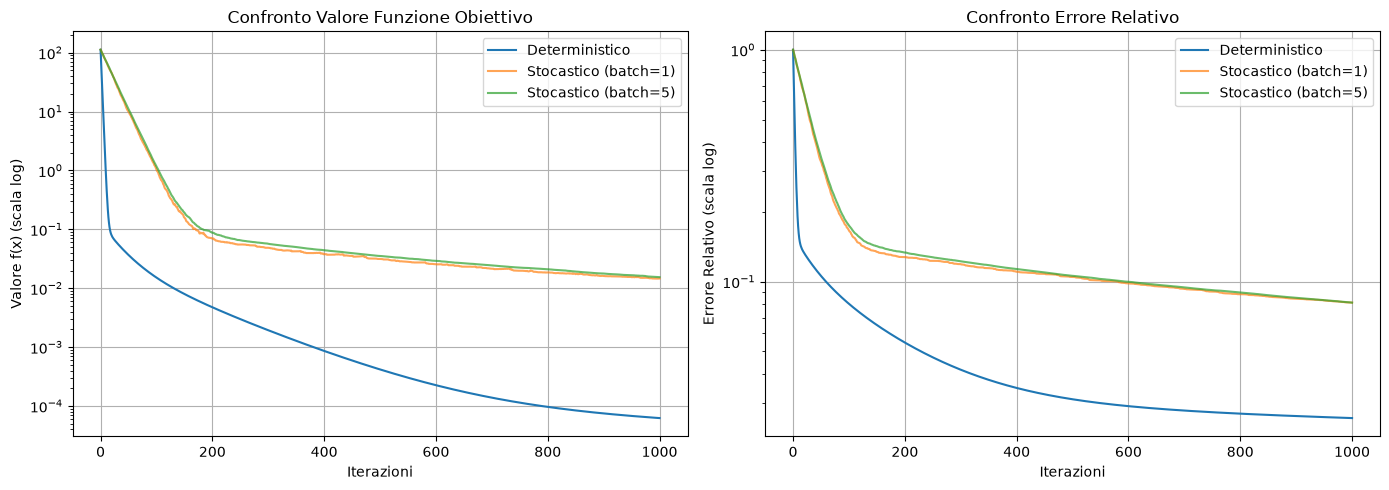

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def backtracking(f, x, grad, alpha=1.0, rho=0.5, c=1e-4):
    while f(x - alpha * grad) > f(x) - c * alpha * np.dot(grad, grad):
        alpha *= rho
    return alpha

def gradient_descent(f, grad_f, x0, x_true, alpha=None, max_iter=1000, tol_grad=1e-6, tol_x=1e-5):
    x_k = np.array(x0, dtype=float)
    storia_f = [f(x_k)]
    storia_err = [np.linalg.norm(x_k - x_true) / np.linalg.norm(x_true)]
    for k in range(max_iter):
        grad = np.array(grad_f(x_k))
        if np.linalg.norm(grad) < tol_grad:
            break
        alpha_k = alpha if alpha is not None else backtracking(f, x_k, grad)
        x_new = x_k - alpha_k * grad
        if np.any(np.isnan(x_new)) or np.any(np.abs(x_new) > 1e5):
            break
        if np.linalg.norm(x_new - x_k) < tol_x:
            break
        x_k = x_new
        storia_f.append(f(x_k))
        storia_err.append(np.linalg.norm(x_k - x_true) / np.linalg.norm(x_true))
    return np.array(storia_f), np.array(storia_err)

def stochastic_gradient_descent(A, b, x0, x_true, alpha=0.001, batch_size=1, max_iter=1000, tol_grad=1e-6):
    m, n = A.shape
    x_k = np.array(x0, dtype=float)
    storia_f = [0.5 * np.linalg.norm(np.dot(A, x_k) - b)**2]
    storia_err = [np.linalg.norm(x_k - x_true) / np.linalg.norm(x_true)]
    for k in range(max_iter):
        indices = np.random.choice(m, size=batch_size, replace=False)
        A_sub = A[indices, :]
        b_sub = b[indices]
        grad = np.dot(A_sub.T, np.dot(A_sub, x_k) - b_sub) * (m / batch_size)
        if np.linalg.norm(grad) < tol_grad:
            break
        x_k = x_k - alpha * grad
        storia_f.append(0.5 * np.linalg.norm(np.dot(A, x_k) - b)**2)
        storia_err.append(np.linalg.norm(x_k - x_true) / np.linalg.norm(x_true))
    return np.array(storia_f), np.array(storia_err)

np.random.seed(42)
n = 10
A = np.random.random((n, n))
x_true = np.ones(n)
b = np.dot(A, x_true)

def f_d(x):
    return 0.5 * np.linalg.norm(np.dot(A, x) - b)**2

def grad_f_d(x):
    return np.dot(A.T, np.dot(A, x) - b)

x0 = np.zeros(n)
f_det, err_det = gradient_descent(f_d, grad_f_d, x0, x_true, alpha=0.01, max_iter=1000)
f_sto1, err_sto1 = stochastic_gradient_descent(A, b, x0, x_true, alpha=0.001, batch_size=1, max_iter=1000)
f_sto5, err_sto5 = stochastic_gradient_descent(A, b, x0, x_true, alpha=0.001, batch_size=5, max_iter=1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(f_det, label='Deterministico')
ax1.plot(f_sto1, label='Stocastico (batch=1)', alpha=0.7)
ax1.plot(f_sto5, label='Stocastico (batch=5)', alpha=0.7)
ax1.set_yscale('log')
ax1.set_xlabel('Iterazioni')
ax1.set_ylabel('Valore f(x) (scala log)')
ax1.set_title('Confronto Valore Funzione Obiettivo')
ax1.legend()
ax1.grid(True)

ax2.plot(err_det, label='Deterministico')
ax2.plot(err_sto1, label='Stocastico (batch=1)', alpha=0.7)
ax2.plot(err_sto5, label='Stocastico (batch=5)', alpha=0.7)
ax2.set_yscale('log')
ax2.set_xlabel('Iterazioni')
ax2.set_ylabel('Errore Relativo (scala log)')
ax2.set_title('Confronto Errore Relativo')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Implementazione dell'SGD (Minibatch): Per risolvere il problema dei minimi quadrati lineari (d), ho implementato il Metodo del Gradiente Stocastico. A differenza dell'approccio deterministico (che calcola il gradiente considerando l'intera matrice $A$ e l'intero vettore $b$ ad ogni passo), l'SGD estrae casualmente un sottoinsieme di dati (minibatch di dimensione $j$) a ogni iterazione per stimare il gradiente. Questo riduce drasticamente il costo computazionale per singola iterazione, rendendo l'algoritmo ideale per dataset molto grandi.

Confronto dei Valori della Funzione Obiettivo: Il grafico mostra chiaramente la differenza dinamica tra i due approcci:

Il metodo deterministico scende in modo regolare e monotonico verso il minimo, sfruttando la direzione di discesa esatta.

I metodi stocastici (batch_size=1 e batch_size=5) mostrano un andamento caratterizzato da oscillazioni (rumore stocastico), poiché ogni iterazione calcola il gradiente su dati differenti.

Confronto dell'Errore Relativo: Tracciando l'errore relativo rispetto alla soluzione esatta $\frac{\Vert{}x_k - x^*\Vert{}}{\Vert{}x^*\Vert{}}$ in scala logaritmica, si osserva l'effetto della dimensione del minibatch:

Un minibatch più piccolo (batch_size=1) introduce maggiore rumore e fluttuazioni nella traiettoria di convergenza.

Aumentando la dimensione del minibatch (batch_size=5), la stima del gradiente diventa più vicina a quella deterministica, riducendo la varianza e stabilizzando il percorso di convergenza verso la soluzione ottimale.